# Individual Assignment I: Data Preparation for Bank Marketing

**GitHub repository**

https://github.com/Kiril-P/ML-fundamentals-2026

Student: Kiril Petrovski


## Setup

For this first part, I focus on two things: finding the target and setting the right order of steps.

The main goal is to avoid leakage. So here I only do basic inspection. Later, I will split the data first, and only after that fit imputers, encoders, scalers, resampling, and feature selection on the training set only.

I keep the notebook simple by showing the code first and then explaining the result briefly.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)

DATA_PATH = Path("data/raw/bank-additional.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH.resolve()}")

# Read the raw assignment dataset exactly once so the notebook stays reproducible.
df = pd.read_csv(DATA_PATH, sep=";")

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Number of columns: {df.shape[1]}")


Loaded dataset from: data/raw/bank-additional.csv
Dataset shape: (4119, 21)
Number of columns: 21


## Task 1: Identifying the Prediction Target

Before doing any preprocessing, I first confirm which column is the target and which columns are only inputs.


In [2]:
print("Columns in the dataset:")
print(df.columns.tolist())
print()
print("First five rows:")
display(df.head())
print()
print("Candidate target column summary:")
print(df["y"].value_counts(dropna=False).rename("count"))


Columns in the dataset:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First five rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Candidate target column summary:
y
no     3668
yes     451
Name: count, dtype: int64


From the dataset and the assignment brief, `y` is the correct target. It tells us whether the client subscribed to the term deposit, which is exactly what we are asked to predict.

Some other columns may look close to the outcome, but they are not the target:

- `duration` is the length of the call. It is known after the call, so it is not the label for this task.
- `poutcome` is the result of an older campaign, not the current one.
- `campaign` is only the number of contacts in the current campaign.

So for this assignment, the target variable is `y`.


## Task Ordering Before Any Fitted Preprocessing

The tasks in the brief are not listed in the order I should do them. So I want to set the order clearly before moving on.

My order is:

1. Identify the target.
2. Do basic inspection of the raw data.
3. Split into train, validation, and test with stratification on `y`.
4. Fit preprocessing steps on training data only.
5. Apply the same fitted steps to validation and test data.
6. Train Logistic Regression.
7. Evaluate on validation first, then use the test set at the end.

The key point is that the split must happen before any step that learns from the data.


In [3]:
task_order = pd.DataFrame(
    [
        {
            "step": "1. Identify target",
            "allowed_information": "Use the column names and the assignment goal.",
            "do_not_use": "Do not use fitted statistics or model results yet.",
            "why_now": "The target tells us what we are predicting and what to stratify on.",
            "leakage_if_moved": "If the target is wrong, the rest of the pipeline is built on the wrong problem.",
        },
        {
            "step": "2. Basic raw-data inspection",
            "allowed_information": "Check shape, dtypes, class counts, NaNs, and values like 'unknown'.",
            "do_not_use": "Do not fit imputers, encoders, scalers, selectors, or resampling yet.",
            "why_now": "This gives a basic view of the data before any training-only steps.",
            "leakage_if_moved": "If I learn preprocessing from the full dataset here, validation and test data leak in.",
        },
        {
            "step": "3. Stratified split",
            "allowed_information": "Use only the raw target labels for stratification.",
            "do_not_use": "Do not learn anything from the full feature set first.",
            "why_now": "After the split, the training set becomes the only place to fit preprocessing.",
            "leakage_if_moved": "If I split later, imputation, scaling, resampling, and selection would already have seen future data.",
        },
        {
            "step": "4. Train-only preprocessing",
            "allowed_information": "Use training data only to fit transformations.",
            "do_not_use": "Validation and test data should only be transformed, not used for fitting.",
            "why_now": "This is the first safe stage for learned preprocessing.",
            "leakage_if_moved": "Future data would affect the fitted parameters and make results look too good.",
        },
        {
            "step": "5. Model fitting and validation",
            "allowed_information": "Fit on processed training data and check results on validation data.",
            "do_not_use": "Do not tune decisions on the test set.",
            "why_now": "Validation is for checking the pipeline before the final test.",
            "leakage_if_moved": "Using the test set too early would weaken the final evaluation.",
        },
    ]
)

display(task_order)


,step,allowed_information,do_not_use,why_now,leakage_if_moved
0,1. Identify target,Use the column names and the assignment goal.,Do not use fitted statistics or model results ...,The target tells us what we are predicting and...,"If the target is wrong, the rest of the pipeli..."
1,2. Basic raw-data inspection,"Check shape, dtypes, class counts, NaNs, and v...","Do not fit imputers, encoders, scalers, select...",This gives a basic view of the data before any...,If I learn preprocessing from the full dataset...
2,3. Stratified split,Use only the raw target labels for stratificat...,Do not learn anything from the full feature se...,"After the split, the training set becomes the ...","If I split later, imputation, scaling, resampl..."
3,4. Train-only preprocessing,Use training data only to fit transformations.,Validation and test data should only be transf...,This is the first safe stage for learned prepr...,Future data would affect the fitted parameters...
4,5. Model fitting and validation,Fit on processed training data and check resul...,Do not tune decisions on the test set.,Validation is for checking the pipeline before...,Using the test set too early would weaken the ...


A wrong order would be to encode, scale, and run SMOTE before the train/validation/test split.

That would cause leakage because:

- the encoder would see categories from all rows,
- the scaler would use values from validation and test rows,
- the resampling step would use information that should stay unseen until evaluation.

This would make the final results look better than they really are.


## Safe Initial Exploration Before Splitting

Here I only do basic checks that are safe before the split. I am not fitting anything yet. I just want to understand the dataset structure, the target balance, and possible missing-value patterns.


In [4]:
print("Dataset shape:", df.shape)
print("Number of observations:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Data types:")
print(df.dtypes.astype(str))
print()

numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)
print()
print("Categorical columns:")
print(categorical_columns)


Dataset shape: (4119, 21)
Number of observations: 4119
Number of columns: 21

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: str

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset has 4,119 rows and 21 columns. It has 10 numerical columns and 11 categorical columns if I include `y`.

This matters later because Logistic Regression needs numeric input. So the categorical columns will need encoding, and the numerical ones may need scaling. At this stage I am only identifying them, not transforming them.


Target counts:
y
no     3668
yes     451
Name: count, dtype: int64

Target percentages:
y
no     89.05
yes    10.95
Name: proportion, dtype: float64


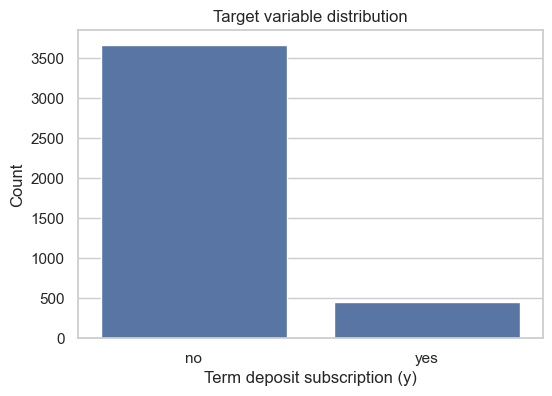

Explicit missing values per column:
age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

Implicit missing-value candidates coded as 'unknown':
default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64

Rows where pdays == 999: 3959 (96.12%)
Duration summary:
count    4119.000000
mean      256.788055
std       254.703736
min         0.000000
25%       103.000000
50%       181.000000
75%       317.000000
max      3643.000000
Name: duration, dtype: float64


In [5]:
target_counts = df["y"].value_counts(dropna=False)
target_percentages = df["y"].value_counts(normalize=True, dropna=False).mul(100).round(2)

print("Target counts:")
print(target_counts)
print()
print("Target percentages:")
print(target_percentages)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target variable distribution")
plt.xlabel("Term deposit subscription (y)")
plt.ylabel("Count")
plt.show()

explicit_missing = df.isna().sum().sort_values(ascending=False)
print("Explicit missing values per column:")
print(explicit_missing)
print()

unknown_counts = (
    df.select_dtypes(include=["object", "string"])
    .eq("unknown")
    .sum()
    .sort_values(ascending=False)
)
unknown_counts = unknown_counts[unknown_counts > 0]

print("Implicit missing-value candidates coded as 'unknown':")
print(unknown_counts)
print()

pdays_999_count = int((df["pdays"] == 999).sum())
pdays_999_pct = round((df["pdays"] == 999).mean() * 100, 2)

print(f"Rows where pdays == 999: {pdays_999_count} ({pdays_999_pct}%)")
print("Duration summary:")
print(df["duration"].describe())


The target is imbalanced: there are 3,668 `no` cases and 451 `yes` cases, or 89.05% versus 10.95%. This already supports using stratified splitting. It also shows that accuracy by itself will not be enough later.

There are no standard `NaN` values in the raw file. But some categorical columns contain `unknown`, so there are still implicit missing values to deal with later. The biggest counts are in `default`, `education`, `housing`, and `loan`.

I also want to flag two columns for later:

- `pdays` is `999` in 3,959 rows, which is 96.12% of the dataset. This looks more like a coded value than a normal number.
- `duration` is measured after the call, so it is not available at prediction time. Because of that, I should not keep it as a normal predictor in the final pipeline.

At this stage I am only flagging these issues. I will make the final preprocessing decisions after the split, using training data only.


## More Raw Exploration

The PDF also asks for summary statistics and visualizations. I am still doing this on the raw dataset only, because I have not reached the split yet.


In [6]:
summary_stats = df[numerical_columns].describe().T.round(2)
print("Summary statistics for numerical columns:")
display(summary_stats)


Summary statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.11,10.31,18.00,32.00,38.00,47.00,88.00
duration,4119.0,256.79,254.70,0.00,103.00,181.00,317.00,3643.00
campaign,4119.0,2.54,2.57,1.00,1.00,2.00,3.00,35.00
pdays,4119.0,960.42,191.92,0.00,999.00,999.00,999.00,999.00
previous,4119.0,0.19,0.54,0.00,0.00,0.00,0.00,6.00
emp.var.rate,4119.0,0.08,1.56,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,4119.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,4119.0,-40.50,4.59,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,4119.0,3.62,1.73,0.64,1.33,4.86,4.96,5.04
nr.employed,4119.0,5166.48,73.67,4963.60,5099.10,5191.00,5228.10,5228.10


The summary table gives a quick overview of the numerical variables. For example, `age` ranges from 18 to 88, while `campaign` goes up to 35, so some clients were contacted many more times than most others. It also confirms again that `pdays` needs special care later because most rows are at `999`, which does not look like a normal measured value.


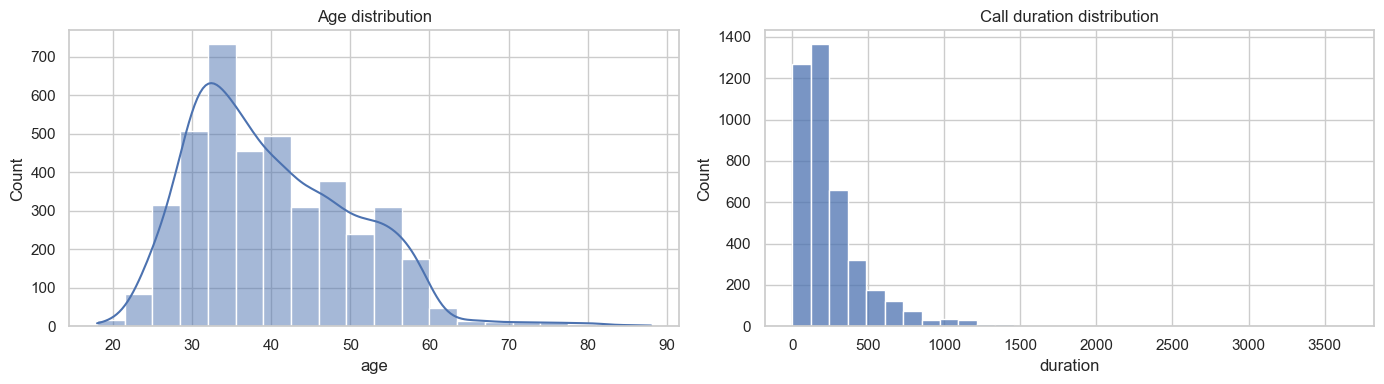

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df, x="age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df, x="duration", bins=30, ax=axes[1])
axes[1].set_title("Call duration distribution")

plt.tight_layout()
plt.show()


These two plots show different things. `age` is fairly spread out, but most clients are still in the middle-age range rather than at the extremes. `duration` is much more right-skewed, with many shorter calls and some very long ones. I also need to remember that `duration` is only known after the call, so I should remove it before building the real prediction pipeline.


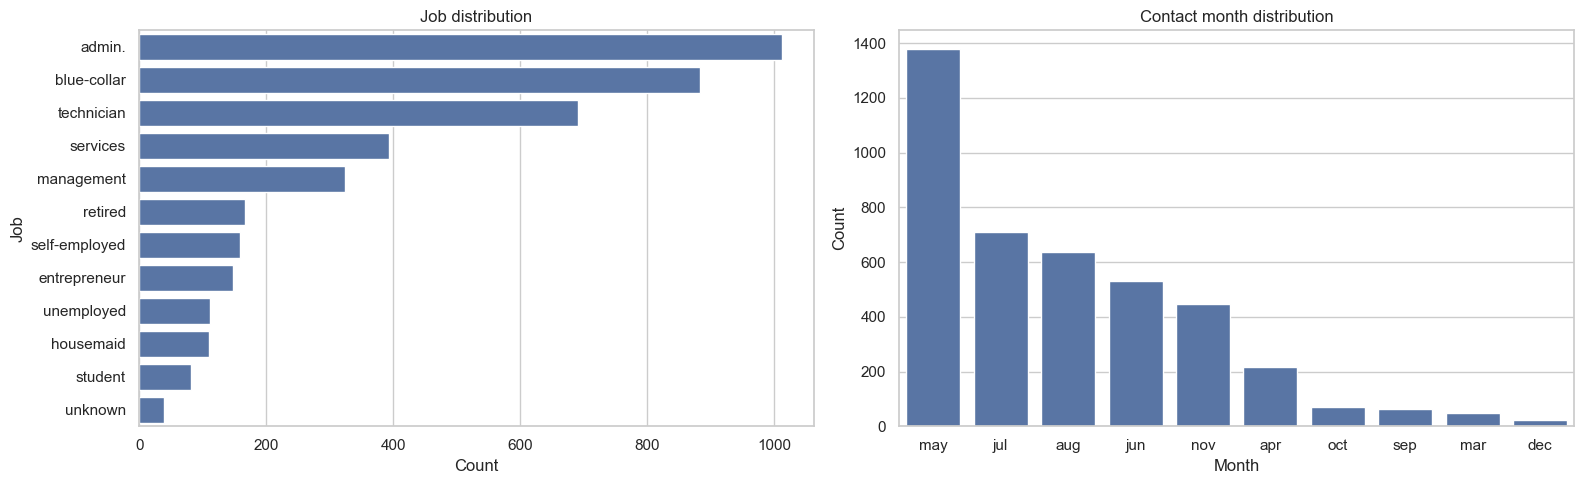

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_order = df["job"].value_counts().index
month_order = df["month"].value_counts().index

sns.countplot(data=df, y="job", order=job_order, ax=axes[0])
axes[0].set_title("Job distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Job")

sns.countplot(data=df, x="month", order=month_order, ax=axes[1])
axes[1].set_title("Contact month distribution")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


The categorical plots also show that the data is not evenly spread. In `job`, the biggest groups are `admin.`, `blue-collar`, and `technician`. In `month`, contacts are heavily concentrated in a few months, especially `may`.

These plots are useful because they show that some categories are common while others are rare. That matters later for encoding and for thinking about how stable some coefficients may be in Logistic Regression.


## Data Splitting

This is where I move from inspection to the actual pipeline. I split now because anything that learns from the data must use training data only. If I delayed the split, later steps like imputation, encoding, scaling, resampling, or feature selection could leak information from validation and test data.

I will use a 60% training split, 20% validation split, and 20% test split. This gives me most of the data for training, while still keeping two separate holdout sets. I also use stratification on `y` because the target is imbalanced, so I want each split to keep a similar class ratio.


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="y")
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
)


def split_summary(name, y_values):
    counts = y_values.value_counts().reindex(["no", "yes"])
    percentages = y_values.value_counts(normalize=True).reindex(["no", "yes"]).mul(100).round(2)
    return {
        "split": name,
        "rows": len(y_values),
        "no_count": counts["no"],
        "yes_count": counts["yes"],
        "no_pct": percentages["no"],
        "yes_pct": percentages["yes"],
    }


split_table = pd.DataFrame(
    [
        split_summary("train", y_train),
        split_summary("validation", y_valid),
        split_summary("test", y_test),
    ]
)

print("Feature matrix shapes:")
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)
print()
print("Target distribution by split:")
display(split_table)


Feature matrix shapes:
X_train: (2471, 20)
X_valid: (824, 20)
X_test: (824, 20)

Target distribution by split:


,split,rows,no_count,yes_count,no_pct,yes_pct
0,train,2471,2200,271,89.03,10.97
1,validation,824,734,90,89.08,10.92
2,test,824,734,90,89.08,10.92


The split is now done before any fitted preprocessing, which is the safe order for the rest of the notebook. The table above should show that the class balance stays very similar across train, validation, and test, which is the reason for using stratification.

From this point on, any fitted or threshold-based decision must use training data only. Validation and test data should only receive the transformations that were learned on the training split.


## Managing Missing Values And Feature Validity

Now that the split is done, I can make train-only preprocessing decisions. In this section I check missingness-related issues on `X_train` only, and I also make a clear decision on features that are not valid at prediction time.


In [10]:
train_explicit_missing = X_train.isna().sum()
train_explicit_missing = train_explicit_missing[train_explicit_missing > 0].sort_values(ascending=False)

train_unknown_counts = (
    X_train.select_dtypes(include=["object", "string"])
    .eq("unknown")
    .sum()
    .sort_values(ascending=False)
)
train_unknown_counts = train_unknown_counts[train_unknown_counts > 0]

train_missing_summary = pd.DataFrame(
    [
        {
            "variable": "default",
            "issue": "'unknown' category",
            "train_count": int(X_train["default"].eq("unknown").sum()),
            "train_pct": round(X_train["default"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "education",
            "issue": "'unknown' category",
            "train_count": int(X_train["education"].eq("unknown").sum()),
            "train_pct": round(X_train["education"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "housing",
            "issue": "'unknown' category",
            "train_count": int(X_train["housing"].eq("unknown").sum()),
            "train_pct": round(X_train["housing"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "loan",
            "issue": "'unknown' category",
            "train_count": int(X_train["loan"].eq("unknown").sum()),
            "train_pct": round(X_train["loan"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "job",
            "issue": "'unknown' category",
            "train_count": int(X_train["job"].eq("unknown").sum()),
            "train_pct": round(X_train["job"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "marital",
            "issue": "'unknown' category",
            "train_count": int(X_train["marital"].eq("unknown").sum()),
            "train_pct": round(X_train["marital"].eq("unknown").mean() * 100, 2),
            "planned_handling": "keep as its own category",
        },
        {
            "variable": "pdays",
            "issue": "sentinel value 999",
            "train_count": int(X_train["pdays"].eq(999).sum()),
            "train_pct": round(X_train["pdays"].eq(999).mean() * 100, 2),
            "planned_handling": "treat 999 as a special code, not a normal day count",
        },
        {
            "variable": "duration",
            "issue": "not available at prediction time",
            "train_count": len(X_train),
            "train_pct": 100.0,
            "planned_handling": "drop before modeling",
        },
    ]
)

print("Explicit missing values in X_train:")
if train_explicit_missing.empty:
    print("No standard NaN values found in X_train.")
else:
    print(train_explicit_missing)

print()
print("'unknown' counts in X_train:")
print(train_unknown_counts)
print()
print("Missingness and feature-validity summary:")
display(train_missing_summary)


Explicit missing values in X_train:
No standard NaN values found in X_train.

'unknown' counts in X_train:
default      492
education    104
housing       55
loan          55
job           20
marital        7
dtype: int64

Missingness and feature-validity summary:


,variable,issue,train_count,train_pct,planned_handling
0,default,'unknown' category,492,19.91,keep as its own category
1,education,'unknown' category,104,4.21,keep as its own category
2,housing,'unknown' category,55,2.23,keep as its own category
3,loan,'unknown' category,55,2.23,keep as its own category
4,job,'unknown' category,20,0.81,keep as its own category
5,marital,'unknown' category,7,0.28,keep as its own category
6,pdays,sentinel value 999,2368,95.83,"treat 999 as a special code, not a normal day ..."
7,duration,not available at prediction time,2471,100.00,drop before modeling


Looking only at `X_train`, there are still no standard `NaN` values. The main issues are the `unknown` categories in several categorical variables, the `999` code in `pdays`, and the fact that `duration` is not available when the prediction would actually be made.

My chosen handling is:

- keep `unknown` as its own category for the affected categorical variables instead of pretending it is an ordinary known value;
- treat `pdays == 999` as a special code, not as a real number of days;
- remove `duration` from the modeling data because it is not available at prediction time.

I am making these decisions now, after the split, so that later fitted steps still learn only from training data.


In [11]:
X_train_model = X_train.drop(columns="duration").copy()
X_valid_model = X_valid.drop(columns="duration").copy()
X_test_model = X_test.drop(columns="duration").copy()

print("Shapes after removing duration from the modeling data:")
print("X_train_model:", X_train_model.shape)
print("X_valid_model:", X_valid_model.shape)
print("X_test_model:", X_test_model.shape)


Shapes after removing duration from the modeling data:
X_train_model: (2471, 19)
X_valid_model: (824, 19)
X_test_model: (824, 19)


Dropping `duration` here is a conceptual decision, not a fitted one. I am not using any statistics from the data to remove it. I am removing it because the problem is to predict using information available at the time of contact, and call duration is only known after the call.


From this point on, the preprocessing uses `X_train_model`, `X_valid_model`, and `X_test_model`. Any encoder, imputer, scaler, resampler, or selector must be fitted on the training data only, then applied to validation and test without refitting.


## Encoding Categorical Variables And Scaling Numerical Variables

The next step is train-only encoding and scaling. This comes after the split and after removing `duration`, because these steps learn from the data and should only use the training set.


In [12]:
X_train_ready = X_train_model.copy()
X_valid_ready = X_valid_model.copy()
X_test_ready = X_test_model.copy()

# Replace the raw pdays code with a cleaner pair of features.
for frame in [X_train_ready, X_valid_ready, X_test_ready]:
    frame["had_previous_contact"] = (frame["pdays"] != 999).astype(int)
    frame["pdays_since_last_contact"] = np.where(frame["pdays"] == 999, 0, frame["pdays"])

X_train_ready = X_train_ready.drop(columns="pdays")
X_valid_ready = X_valid_ready.drop(columns="pdays")
X_test_ready = X_test_ready.drop(columns="pdays")

categorical_features_model = X_train_ready.select_dtypes(exclude=[np.number]).columns.tolist()
numerical_features_model = X_train_ready.select_dtypes(include=[np.number]).columns.tolist()

categorical_strategy = pd.DataFrame(
    [
        {"variable": "job", "type": "nominal", "encoding": "one-hot", "reason": "no natural order"},
        {"variable": "marital", "type": "nominal", "encoding": "one-hot", "reason": "no natural order"},
        {"variable": "education", "type": "ordinal meaning", "encoding": "one-hot", "reason": "order is not clean enough for a single numeric scale"},
        {"variable": "default", "type": "nominal", "encoding": "one-hot", "reason": "categories are labels, not ranks"},
        {"variable": "housing", "type": "nominal", "encoding": "one-hot", "reason": "categories are labels, not ranks"},
        {"variable": "loan", "type": "nominal", "encoding": "one-hot", "reason": "categories are labels, not ranks"},
        {"variable": "contact", "type": "nominal", "encoding": "one-hot", "reason": "contact type has no order"},
        {"variable": "month", "type": "nominal", "encoding": "one-hot", "reason": "calendar order does not imply a linear effect"},
        {"variable": "day_of_week", "type": "nominal", "encoding": "one-hot", "reason": "weekday names are not a ranked scale"},
        {"variable": "poutcome", "type": "nominal", "encoding": "one-hot", "reason": "campaign outcomes are labels"},
    ]
)

binary_features = ["had_previous_contact"]
scaled_numerical_features = [
    feature for feature in numerical_features_model if feature not in binary_features
]

print("Categorical features used for encoding:")
print(categorical_features_model)
print()
print("Numerical features used for scaling:")
print(scaled_numerical_features)
print()
print("Binary features kept without scaling:")
print(binary_features)
print()
print("Encoding plan:")
display(categorical_strategy)


Categorical features used for encoding:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical features used for scaling:
['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_since_last_contact']

Binary features kept without scaling:
['had_previous_contact']

Encoding plan:


,variable,type,encoding,reason
0,job,nominal,one-hot,no natural order
1,marital,nominal,one-hot,no natural order
2,education,ordinal meaning,one-hot,order is not clean enough for a single numeric...
3,default,nominal,one-hot,"categories are labels, not ranks"
4,housing,nominal,one-hot,"categories are labels, not ranks"
5,loan,nominal,one-hot,"categories are labels, not ranks"
6,contact,nominal,one-hot,contact type has no order
7,month,nominal,one-hot,calendar order does not imply a linear effect
8,day_of_week,nominal,one-hot,weekday names are not a ranked scale
9,poutcome,nominal,one-hot,campaign outcomes are labels


I recomputed the feature groups from `X_train_model`, not from the full raw dataset. Most categorical variables are nominal, so one-hot encoding is the safest choice. `education` has some order in meaning, but I still use one-hot encoding because the gaps between levels are not clear enough for a single numeric code.

I also replaced the raw `pdays` column with two features: one tells me whether there was any previous contact, and the other keeps the day count only when it exists. This is easier to interpret than treating `999` like a normal number.


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()

X_train_cat = categorical_encoder.fit_transform(X_train_ready[categorical_features_model])
X_valid_cat = categorical_encoder.transform(X_valid_ready[categorical_features_model])
X_test_cat = categorical_encoder.transform(X_test_ready[categorical_features_model])

encoded_feature_names = categorical_encoder.get_feature_names_out(categorical_features_model)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_feature_names, index=X_train_ready.index)
X_valid_cat_df = pd.DataFrame(X_valid_cat, columns=encoded_feature_names, index=X_valid_ready.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_feature_names, index=X_test_ready.index)

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_ready[scaled_numerical_features]),
    columns=scaled_numerical_features,
    index=X_train_ready.index,
)
X_valid_num_scaled = pd.DataFrame(
    scaler.transform(X_valid_ready[scaled_numerical_features]),
    columns=scaled_numerical_features,
    index=X_valid_ready.index,
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_ready[scaled_numerical_features]),
    columns=scaled_numerical_features,
    index=X_test_ready.index,
)

X_train_binary = X_train_ready[binary_features].copy()
X_valid_binary = X_valid_ready[binary_features].copy()
X_test_binary = X_test_ready[binary_features].copy()

X_train_processed = pd.concat([X_train_num_scaled, X_train_binary, X_train_cat_df], axis=1)
X_valid_processed = pd.concat([X_valid_num_scaled, X_valid_binary, X_valid_cat_df], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_binary, X_test_cat_df], axis=1)

print("Processed dataset shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_valid_processed:", X_valid_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print()
print("Number of original modeling features:", X_train_model.shape[1])
print("Number of processed training features:", X_train_processed.shape[1])


Processed dataset shapes:
X_train_processed: (2471, 63)
X_valid_processed: (824, 63)
X_test_processed: (824, 63)

Number of original modeling features: 19
Number of processed training features: 63


The encoder and scaler are fitted on `X_train_ready` only. Then I apply the same fitted objects to validation and test, which keeps the pipeline leakage-safe.

One-hot encoding increases the number of columns because one categorical variable can turn into several dummy columns. For Logistic Regression, this is useful because it lets the model give separate coefficients to different categories instead of forcing a fake numeric order.


I use standardization for the numerical variables because Logistic Regression is sensitive to feature scale. If one variable has much larger values than another, it can dominate the optimization and make the coefficients harder to compare.

Scaling also matters for regularization. After standardization, the penalty is applied on a more comparable scale across the numerical features. I left the binary indicator `had_previous_contact` unscaled because it is already on a simple 0/1 scale.


## Feature Selection

Now I do feature selection on the training data only. I check three things: very low variance features, highly correlated numerical features, and conceptual removals that help keep the model realistic and stable.


In [14]:
low_variance_threshold = 0.005

feature_variances = X_train_processed.var().sort_values()
low_variance_features = feature_variances[feature_variances < low_variance_threshold].index.tolist()

numerical_correlation = X_train_ready[numerical_features_model].corr().abs()
correlation_threshold = 0.90
upper_triangle = numerical_correlation.where(
    np.triu(np.ones(numerical_correlation.shape), k=1).astype(bool)
)

high_correlation_pairs = []
for column in upper_triangle.columns:
    strong_matches = upper_triangle[column].dropna()
    strong_matches = strong_matches[strong_matches >= correlation_threshold]
    for other_feature, corr_value in strong_matches.items():
        high_correlation_pairs.append(
            {
                "feature_1": other_feature,
                "feature_2": column,
                "correlation": round(float(corr_value), 4),
            }
        )

high_correlation_pairs = pd.DataFrame(high_correlation_pairs)
correlated_drop_features = ["emp.var.rate", "nr.employed"]

selected_drop_features = sorted(set(low_variance_features + correlated_drop_features))

X_train_selected = X_train_processed.drop(columns=selected_drop_features, errors="ignore")
X_valid_selected = X_valid_processed.drop(columns=selected_drop_features, errors="ignore")
X_test_selected = X_test_processed.drop(columns=selected_drop_features, errors="ignore")

print("Low-variance threshold:", low_variance_threshold)
print("Low-variance features to drop:")
print(low_variance_features)
print()
print("High-correlation pairs (|r| >= 0.90):")
display(high_correlation_pairs)
print("Correlated features chosen for removal:")
print(correlated_drop_features)
print()
print("Final dropped features:")
print(selected_drop_features)
print()
print("Shapes after feature selection:")
print("X_train_selected:", X_train_selected.shape)
print("X_valid_selected:", X_valid_selected.shape)
print("X_test_selected:", X_test_selected.shape)


Low-variance threshold: 0.005
Low-variance features to drop:
['education_illiterate', 'default_yes', 'marital_unknown']

High-correlation pairs (|r| >= 0.90):


,feature_1,feature_2,correlation
0,emp.var.rate,euribor3m,0.9700
1,euribor3m,nr.employed,0.9417


Correlated features chosen for removal:
['emp.var.rate', 'nr.employed']

Final dropped features:
['default_yes', 'education_illiterate', 'emp.var.rate', 'marital_unknown', 'nr.employed']

Shapes after feature selection:
X_train_selected: (2471, 58)
X_valid_selected: (824, 58)
X_test_selected: (824, 58)


I used a very small variance threshold of `0.005`, so I only remove features that are almost constant in the training data. This mainly catches very rare dummy columns after one-hot encoding. I do not want to drop too many categories just because they are not common.

For correlation, I only look at the numerical features from the training data and I use a threshold of `0.90`. The strongest overlap is between the macroeconomic variables. I keep `euribor3m` and remove `emp.var.rate` and `nr.employed`, because they carry very similar information and could make Logistic Regression coefficients less stable.


This step must use training data only. If I selected features using the full dataset, then the validation and test sets would already influence which columns survive. That would leak information and make the later evaluation look better than it really is.

From now on, the modeling stages should use `X_train_selected`, `X_valid_selected`, and `X_test_selected`.


## Addressing Class Imbalance And Training Logistic Regression

The final modeling stage starts by checking the class balance in the training set. Then I apply a resampling method on the training data only, fit Logistic Regression, and evaluate on the validation set.


In [15]:
train_class_summary = pd.DataFrame(
    {
        "count": y_train.value_counts().reindex(["no", "yes"]),
        "percentage": y_train.value_counts(normalize=True).reindex(["no", "yes"]).mul(100).round(2),
    }
)

print("Training-set class distribution:")
display(train_class_summary)


Training-set class distribution:


,count,percentage
y,,
no,2200,89.03
yes,271,10.97


The training set is still imbalanced, so I should not just ignore it. I will use `RandomOverSampler` on the training data only.

I chose this instead of SMOTE because it is the simpler and safer option here. After one-hot encoding, synthetic interpolation can create values between categories, while random oversampling keeps real training examples and only duplicates minority cases. Validation and test data stay unchanged.


In [16]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_selected, y_train)

resampled_class_summary = pd.DataFrame(
    {
        "count": y_train_resampled.value_counts().reindex(["no", "yes"]),
        "percentage": y_train_resampled.value_counts(normalize=True).reindex(["no", "yes"]).mul(100).round(2),
    }
)

print("Class distribution after RandomOverSampler:")
display(resampled_class_summary)

majority_class = y_train.value_counts().idxmax()
y_valid_zero_rule = pd.Series(majority_class, index=y_valid.index)
zero_rule_accuracy = accuracy_score(y_valid, y_valid_zero_rule)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

y_valid_pred = log_reg.predict(X_valid_selected)

validation_metrics = pd.DataFrame(
    {
        "metric": ["Accuracy", "Precision", "Recall", "Zero Rule Accuracy"],
        "value": [
            round(accuracy_score(y_valid, y_valid_pred), 4),
            round(precision_score(y_valid, y_valid_pred, pos_label="yes", zero_division=0), 4),
            round(recall_score(y_valid, y_valid_pred, pos_label="yes", zero_division=0), 4),
            round(zero_rule_accuracy, 4),
        ],
    }
)

valid_confusion = pd.DataFrame(
    confusion_matrix(y_valid, y_valid_pred, labels=["no", "yes"]),
    index=["Actual no", "Actual yes"],
    columns=["Predicted no", "Predicted yes"],
)

print("Validation metrics:")
display(validation_metrics)
print("Validation confusion matrix:")
display(valid_confusion)


Class distribution after RandomOverSampler:


,count,percentage
y,,
no,2200,50.0
yes,2200,50.0


Validation metrics:


,metric,value
0,Accuracy,0.8216
1,Precision,0.3273
2,Recall,0.6000
3,Zero Rule Accuracy,0.8908


Validation confusion matrix:


,Predicted no,Predicted yes
Actual no,623,111
Actual yes,36,54


The resampling step is part of training, so it is applied only to `X_train_selected` and `y_train`. I do not touch the validation or test sets, because they should keep the original class balance.

The Zero Rule baseline predicts only the majority class from the training set. This gives me a simple reference point. If Logistic Regression cannot beat that baseline in a sensible way, then the preprocessing pipeline would need to be checked again.

At this stage I evaluate only on the validation set. The test set is still untouched and should stay that way until the very end.


## Validation Results Interpretation

On the validation set, Logistic Regression got accuracy `0.8216`, precision `0.3273`, and recall `0.6000`. The Zero Rule baseline accuracy is `0.8908`, so the model does worse on accuracy alone.

I do not think this means the pipeline failed. The dataset is strongly imbalanced, so a model that always predicts `no` gets high accuracy very easily. The Logistic Regression model gives up some accuracy, but it finds more of the minority `yes` cases. That is why recall is more useful here than accuracy by itself.

So my reading is that the pipeline is behaving in a sensible way: the model is trying to detect subscriptions instead of just following the majority class.


## Alternatives Considered

I also considered other choices, but I did not use them in the final pipeline:

- For `unknown`, I could have imputed the most common category, but I kept `unknown` as its own category because it may carry information and I did not want to invent a known value.
- For `pdays`, I could have left `999` as a normal number, but that would mix a code with real day counts, so I changed it into more meaningful features.
- For scaling, I could have used min-max scaling, but standardization fits Logistic Regression better because it helps optimization and keeps coefficients on a more comparable scale.
- For imbalance handling, I could have used `class_weight='balanced'` or SMOTE. I chose random oversampling because it is simple and it keeps real minority examples instead of creating synthetic points after one-hot encoding.
- For feature selection, I could have kept all correlated macroeconomic variables, but that would make the linear model harder to interpret and could make the coefficients less stable.


## Final Test Set Check

At this point I have finished the validation-stage decisions, so I can use the test set once as a final check. I do not change the pipeline after looking at these test results.


In [17]:
y_test_pred = log_reg.predict(X_test_selected)

test_metrics = pd.DataFrame(
    {
        "metric": ["Accuracy", "Precision", "Recall"],
        "value": [
            round(accuracy_score(y_test, y_test_pred), 4),
            round(precision_score(y_test, y_test_pred, pos_label="yes", zero_division=0), 4),
            round(recall_score(y_test, y_test_pred, pos_label="yes", zero_division=0), 4),
        ],
    }
)

test_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred, labels=["no", "yes"]),
    index=["Actual no", "Actual yes"],
    columns=["Predicted no", "Predicted yes"],
)

print("Test metrics:")
display(test_metrics)
print("Test confusion matrix:")
display(test_confusion)


Test metrics:


,metric,value
0,Accuracy,0.7949
1,Precision,0.2888
2,Recall,0.6000


Test confusion matrix:


,Predicted no,Predicted yes
Actual no,601,133
Actual yes,36,54


The test results are similar to the validation results: accuracy is `0.7949`, precision is `0.2888`, and recall is `0.6000`. This is a good sign because it means the model behaviour is fairly consistent and the validation result was not completely misleading.

The final model is still not strong if I only care about precision or overall accuracy. But for this assignment, that is acceptable. The main goal was to build the pipeline in the right order, avoid leakage, and make the preprocessing decisions carefully.
